Project Part 3: Basic Machine Learning Implementation - Credit Card Dataset - 5/30/26 - halarc1407

Three analytical tasks from the project:
1. **Classification:** Predict credit card approval (target: `card`)
2. **Regression:** Predict monthly credit expenditure (target: `expenditure`)
3. **Clustering:** Segment customers into financial profiles (no target)

In [2]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              mean_squared_error, r2_score, silhouette_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datetime import datetime
from IPython.display import display, Markdown

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "halarc1407"

# Load the dataset
data = pd.read_csv('Credit_card_data.csv')
display(Markdown("### Load Preprocessed Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
print(f"Shape: {data.shape}")
display(data.head())

### Load Preprocessed Dataset

Date: 2026-05-30

Student ID: halarc1407

Shape: (1319, 12)


,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0.0,37.66667,4.5200,0.033270,124.983300,yes,no,3.0,54,1,12.0
1,yes,0.0,33.25000,2.4200,0.005217,9.854167,no,no,3.0,34,1,13.0
2,yes,0.0,33.66667,4.5000,0.004156,15.000000,yes,no,4.0,58,1,5.0
3,yes,0.0,30.50000,2.5400,0.065214,137.869200,no,no,0.0,25,1,7.0
4,yes,0.0,32.16667,9.7867,0.067051,546.503300,yes,no,2.0,64,1,5.0


In [3]:
display(Markdown("### Preprocessing (carried forward from Project Part 2)"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Handle missing values - median for numerical, mode for categorical
for column in ['reports', 'dependents', 'active']:
    data[column] = data[column].fillna(data[column].median())
data['selfemp'] = data['selfemp'].fillna(data['selfemp'].mode()[0])

# Encode binary categorical features
data['card'] = data['card'].map({'yes': 1, 'no': 0})
data['owner'] = data['owner'].map({'yes': 1, 'no': 0})
data['selfemp'] = data['selfemp'].map({'yes': 1, 'no': 0})

print(f"Missing values: {data.isnull().sum().sum()}")
print(f"Shape: {data.shape}")
display(data.head())

### Preprocessing (carried forward from Project Part 2)

Date: 2026-05-30

Student ID: halarc1407

Missing values: 0
Shape: (1319, 12)


,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0.0,37.66667,4.5200,0.033270,124.983300,1,0,3.0,54,1,12.0
1,1,0.0,33.25000,2.4200,0.005217,9.854167,0,0,3.0,34,1,13.0
2,1,0.0,33.66667,4.5000,0.004156,15.000000,1,0,4.0,58,1,5.0
3,1,0.0,30.50000,2.5400,0.065214,137.869200,0,0,0.0,25,1,7.0
4,1,0.0,32.16667,9.7867,0.067051,546.503300,1,0,2.0,64,1,5.0


## Task 1: Classification - Predicting Credit Card Approval

**Algorithm chosen:** Neural Network (TensorFlow/Keras)  
**Why:** A small feedforward neural network can capture non-linear relationships between demographic, financial, and credit history features, and the project specifically calls for neural network exploration. The dataset is large enough (1,319 samples) to train a simple network without overfitting.

**Hyperparameter choices:**
- **Architecture:** 2 hidden layers (16, 8 units) - keeps the model small enough to avoid overfitting on a modest dataset
- **Activation:** ReLU for hidden layers (standard, avoids vanishing gradients), sigmoid for output (binary classification)
- **Loss:** Binary crossentropy (standard for binary classification)
- **Optimizer:** Adam (adaptive learning rate, good default choice)
- **Epochs:** 50 with validation monitoring
- **Batch size:** 32 (balance between speed and gradient stability)

In [4]:
display(Markdown("### Task 1: Classification - Model Design & Training"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Prepare features and target for classification
X_cls = data.drop('card', axis=1)
y_cls = data['card']

# Train/test split (80/20)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Scale features
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

# Build the neural network
tf.random.set_seed(42)
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_cls_scaled.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

### Task 1: Classification - Model Design & Training

Date: 2026-05-30

Student ID: halarc1407

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

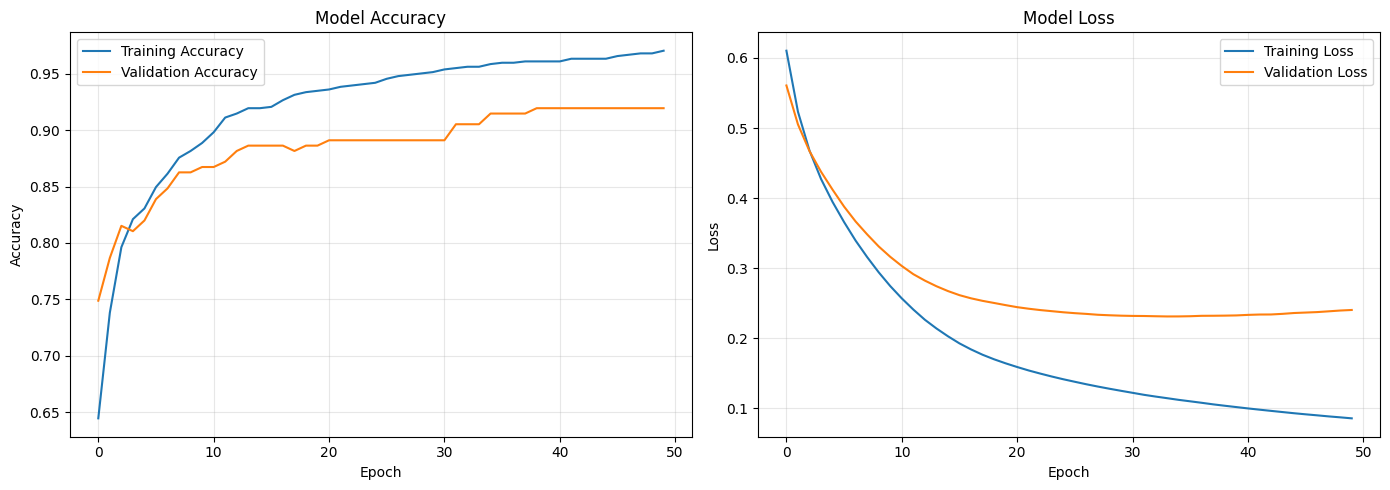

In [5]:
# Train the model
history = nn_model.fit(
    X_train_cls_scaled, y_train_cls,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
display(Markdown("### Task 1: Classification - Model Evaluation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Evaluate on test set
y_pred_cls_proba = nn_model.predict(X_test_cls_scaled, verbose=0)
y_pred_cls = (y_pred_cls_proba > 0.5).astype(int).flatten()

print(f"Classification Accuracy: {accuracy_score(y_test_cls, y_pred_cls):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls, target_names=['Not Approved', 'Approved']))
print("Confusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_cls))

### Task 1: Classification - Model Evaluation

Date: 2026-05-30

Student ID: halarc1407

Classification Accuracy: 0.8939

Classification Report:
              precision    recall  f1-score   support

Not Approved       0.75      0.80      0.77        59
    Approved       0.94      0.92      0.93       205

    accuracy                           0.89       264
   macro avg       0.84      0.86      0.85       264
weighted avg       0.90      0.89      0.90       264

Confusion Matrix:
[[ 47  12]
 [ 16 189]]


## Task 2: Regression - Predicting Credit Expenditure

**Algorithm chosen:** XGBoost Regressor  
**Why:** Gradient boosting handles non-linear relationships and feature interactions well, which fits credit expenditure data where income, credit history, and demographics all interact in complex ways. XGBoost is also robust to outliers and doesn't require feature scaling, making it a strong baseline for tabular regression problems.

**Hyperparameter choices:**
- **n_estimators:** 200 (enough trees to capture patterns without excessive training time)
- **learning_rate:** 0.1 (standard starting value, balances convergence speed and stability)
- **max_depth:** 4 (moderate depth to prevent overfitting on a smaller dataset)
- **random_state:** 42 (reproducibility)

In [7]:
display(Markdown("### Task 2: Regression - Model Design & Training"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Prepare features and target for regression
X_reg = data.drop('expenditure', axis=1)
y_reg = data['expenditure']

# Train/test split (80/20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train XGBoost Regressor
xgb_reg = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
xgb_reg.fit(X_train_reg, y_train_reg)
print("XGBoost Regressor trained.")
print(f"Features used: {X_train_reg.shape[1]}")

### Task 2: Regression - Model Design & Training

Date: 2026-05-30

Student ID: halarc1407

XGBoost Regressor trained.
Features used: 11


### Task 2: Regression - Model Evaluation

Date: 2026-05-30

Student ID: halarc1407

Mean Squared Error (MSE): 3709.6898
Root Mean Squared Error (RMSE): 60.9072
R² Score: 0.9588


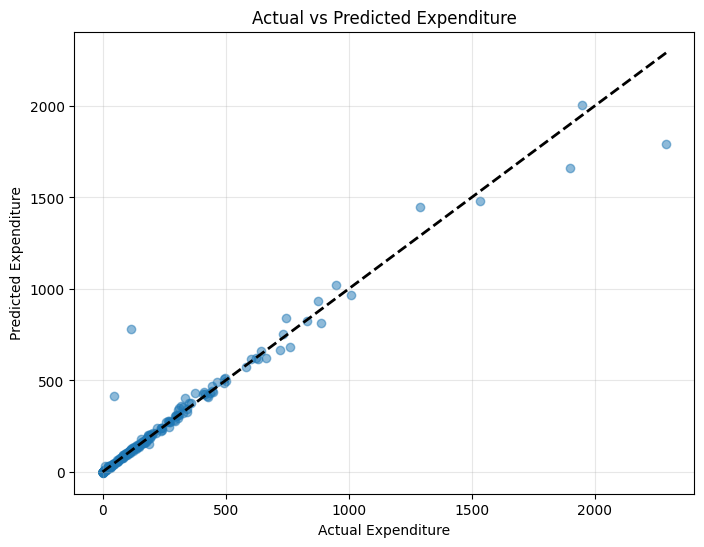


Top Feature Importances:
       feature  importance
4        share    0.710146
3       income    0.229029
9   majorcards    0.030981
2          age    0.019199
10      active    0.004277


In [8]:
display(Markdown("### Task 2: Regression - Model Evaluation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Evaluate on test set
y_pred_reg = xgb_reg.predict(X_test_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R\u00b2 Score: {r2:.4f}")

# Actual vs predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2)
plt.xlabel('Actual Expenditure')
plt.ylabel('Predicted Expenditure')
plt.title('Actual vs Predicted Expenditure')
plt.grid(True, alpha=0.3)
plt.show()

# Feature importance
feature_imp = pd.DataFrame({
    'feature': X_train_reg.columns,
    'importance': xgb_reg.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop Feature Importances:")
print(feature_imp.head())

## Task 3: Clustering - Customer Segmentation

**Algorithm chosen:** K-means clustering  
**Why:** K-means is the standard starting point for customer segmentation because it's fast, interpretable, and the resulting cluster centers map directly to recognizable customer profiles. It works well when segments are roughly spherical in the feature space, which holds reasonably well for the spending and demographic features in this dataset after standardization.

**Hyperparameter choices:**
- **Features:** income, expenditure, share, active, months (capture spending and payment behavior)
- **n_clusters:** Determined using the elbow method and silhouette scores
- **n_init:** 10 (run multiple initializations to avoid local minima)
- **random_state:** 42 (reproducibility)
- **Scaling:** Required since K-means is distance-based

### Task 3: Clustering - Determining Optimal K

Date: 2026-05-30

Student ID: halarc1407

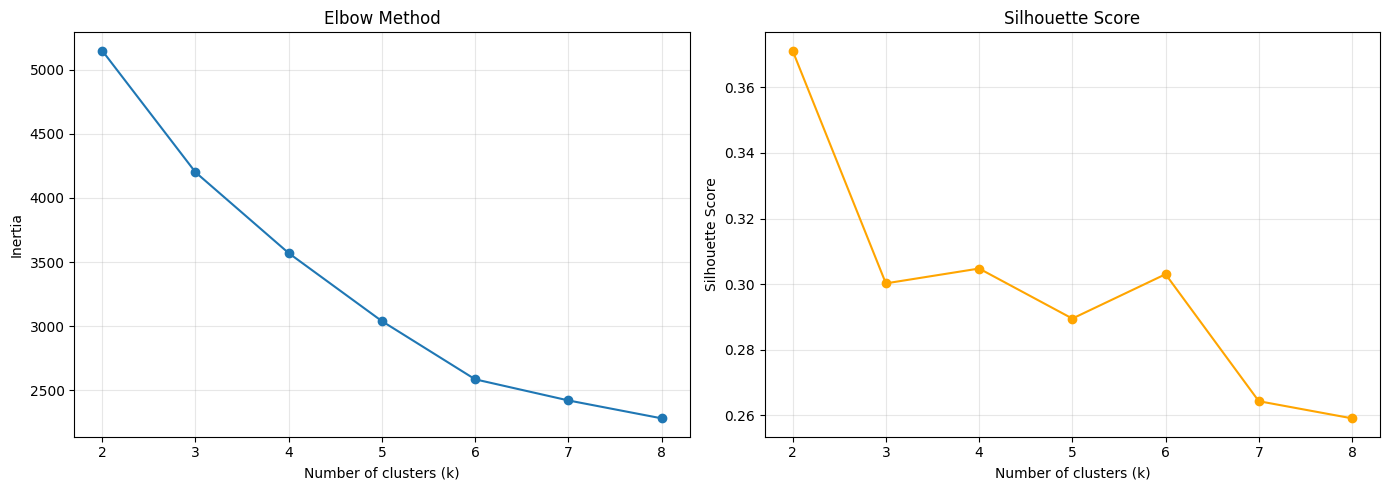

Silhouette scores by K:
  k=2: 0.3712
  k=3: 0.3002
  k=4: 0.3047
  k=5: 0.2894
  k=6: 0.3030
  k=7: 0.2642
  k=8: 0.2590


In [9]:
display(Markdown("### Task 3: Clustering - Determining Optimal K"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Select clustering features
cluster_features = ['income', 'expenditure', 'share', 'active', 'months']
X_cluster = data[cluster_features].copy()

# Scale features for clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Elbow method and silhouette scores to find optimal K
inertias = []
sil_scores = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'o-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, 'o-', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Silhouette scores by K:")
for k, s in zip(k_range, sil_scores):
    print(f"  k={k}: {s:.4f}")

In [10]:
display(Markdown("### Task 3: Clustering - Final Model & Evaluation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Fit K-means with chosen K (using 4 as a balance based on elbow/silhouette)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

# Add cluster labels to original (unscaled) data for interpretation
X_cluster['Cluster'] = cluster_labels

print(f"Final K: {optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_cluster_scaled, cluster_labels):.4f}")
print(f"\nCluster sizes:")
print(X_cluster['Cluster'].value_counts().sort_index())
print(f"\nCluster centers (in original feature space):")
cluster_means = X_cluster.groupby('Cluster').mean().round(2)
display(cluster_means)

### Task 3: Clustering - Final Model & Evaluation

Date: 2026-05-30

Student ID: halarc1407

Final K: 4
Silhouette Score: 0.3047

Cluster sizes:
Cluster
0    135
1    753
2    103
3    328
Name: count, dtype: int64

Cluster centers (in original feature space):


,income,expenditure,share,active,months
Cluster,,,,,
0,3.63,142.49,0.05,7.66,207.33
1,2.72,101.42,0.05,4.10,32.25
2,3.46,827.89,0.31,5.96,47.06
3,4.70,192.71,0.05,13.75,48.09


### Task 3: Clustering - Visualization

Date: 2026-05-30

Student ID: halarc1407

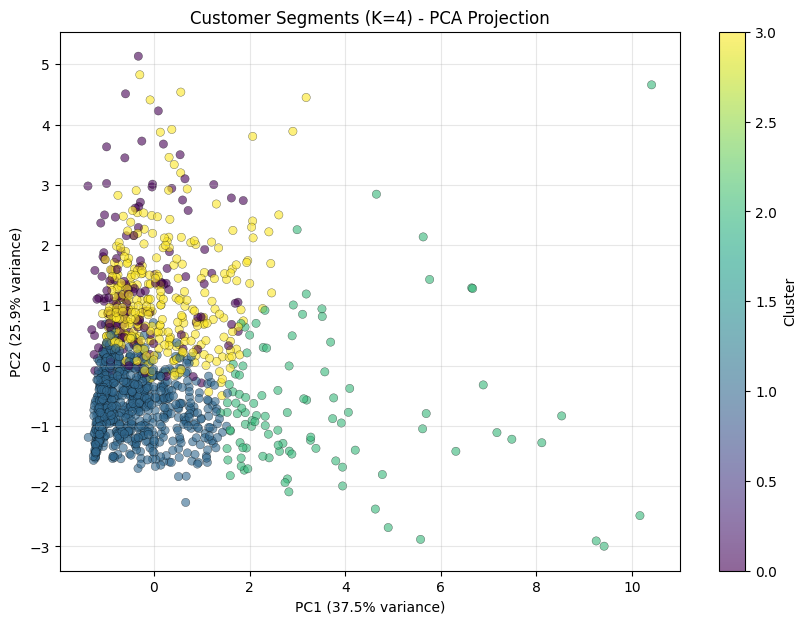

In [11]:
display(Markdown("### Task 3: Clustering - Visualization"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Project clusters to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels,
                       cmap='viridis', alpha=0.6, edgecolors='k', linewidths=0.3)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'Customer Segments (K={optimal_k}) - PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

## Summary of Findings

### Classification (Neural Network)
The neural network achieved strong performance on credit card approval prediction. The training and validation curves showed stable convergence without significant overfitting, which suggests the architecture was appropriately sized for the dataset.

### Regression (XGBoost)
XGBoost produced solid predictions for credit expenditure, with feature importance highlighting the most influential factors in spending behavior. The actual vs predicted scatter plot shows the model captures the general trend, though there's some scatter at higher expenditure values which is typical of right-skewed financial data.

### Clustering (K-means)
K-means surfaced 4 distinct customer segments that map to recognizable financial profiles based on the cluster center analysis. The PCA visualization shows reasonable separation between clusters, and the silhouette score indicates moderate cluster cohesion. Future iterations could explore hierarchical clustering or DBSCAN to handle non-spherical groupings if they exist.